## Basic trip over a real-world graph + energy module 
In this notebook, we set up a basic simulation where one vessel moves over a real-world graph. The vessel will sail from a location in the Maasvlakte, to a location near the Kreekrak locks. We will attempt to add the energy module from notebook 0103 to this with the goal of estimating the energy consumption along this route. (constant depth and speed) 

## 0. Import libraries

In [1]:
# package(s) used for creating and geo-locating the graph
import networkx as nx
import shapely

# package(s) related to the simulation (creating the vessel, running the simulation)
import datetime
import simpy
import opentnsim
import opentnsim.fis as fis
from opentnsim.core.logutils import logbook2eventtable
from opentnsim.core.plotutils import generate_vessel_gantt_chart
# packages added from 0103 notebook
from opentnsim.energy.logutils import (
    add_energy_attributes_to_eventtable,
    add_fuel_attributes_to_event_table,
    add_H2_attributes_to_event_table
)
from opentnsim.graph import mixins as graph_module

# package(s) needed for inspecting the output
import pandas as pd
import geopandas as gpd

# package(s) needed for plotting
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# plot libraries
import folium

import numpy as np

print("This notebook is executed with OpenTNSim version {}".format(opentnsim.__version__))

This notebook is executed with OpenTNSim version 2.2.2.dev47+gbe28de4fe.d20260122


## 0. Load useful methods 

### A) Network functions

In [2]:
# Deze wel zelf bedacht! 
def safe_remove_edge(G, u, v):
    if G.has_edge(u, v):
        G.remove_edge(u, v)
        print(f"Removed edge: {u} -> {v}")
    else:
        print(f"Edge {u} -> {v} does not exist (already removed).")

In [3]:
# From Segers
def find_closest_node(G, point):
    """find the closest node on the graph from a given point"""
    
    distance = np.full((len(G.nodes)), fill_value=np.nan)
    for ii, n in enumerate(G.nodes):
        distance[ii] = point.distance(G.nodes[n]['geometry'])
    name_node = list(G.nodes)[np.argmin(distance)]
    distance_node = np.min(distance)
    
    return name_node, distance_node

In [4]:
# From Segers(not used yet) 
def find_closest_edge(G, point):
    """find the closest edge on the graph from a given point"""
    
    distance = np.full((len(G.edges)), fill_value=np.nan)
    for ii, e in enumerate(G.edges):
        distance[ii] = point.distance(G.edges[e]['geometry'])
    name_edge = list(G.edges)[np.argmin(distance)]
    distance_edge = np.min(distance)
    
    return name_edge, distance_edge

In [5]:
# Frem Segers (not used yet) 
def edge_length(edge):
    """compute the great circle length of an edge
    The network version 0.1 contains the lat/lon distance in a length property. 
    But we need the "great circle" or projected distance. 
    Let's define a function to recompute it.
    """
    
    # get the geometry
    geom = edge['geometry']
    # get lon, lat
    lats, lons = np.array(geom).T
    # this requires pyproj 2.3.0
    distance = geod.line_length(lons, lats)

    return distance

### Other methods
Segers also introduces these methods. But I believe those are not needed in the current opentnsim version in combination with the energy module. 

B) Metods to calculate vessel properties <br>
C) Methods to calculate the resistance, power and corresponding emissions <br>
D) Calculate the energy use and emission per time step

### 1. Define object classes

--> moved this to later just before 3. Run simulation 

### 2. Create graph
Next we create a network (a graph) along which the vessel can move. For this case we use the Fairway Information System graph, and make the vessel sail from a container terminal at the Maasvlakte to the Kreekrak locks

#### 2.1 Load FIS graph

In [6]:
# load the processed version from the Fairway Information System graph provided by Rijkswaterstaat
# For FIS version 0.3 
FG = fis.load_network(version="0.3")

# Trying out for EuRIS
# FG = fis.load_network(network="euris", version="0.1")

# Make graph directed 
FG = FG.to_directed()

In [7]:
# Printing the data per edge to see what the names are. Check if there is water depth info
for u, v, data in FG.edges(data=True):
    print (u, "->", v)
    print(data)
    break

8861095 -> 8864054
{'GeoType': 'section', 'Name': 'Vaarwegvak van 0 tot 2 - H', 'Length': 2.346, 'GeneralDepth': nan, 'GeneralLength': nan, 'GeneralWidth': nan, 'SeaFairingDepth': nan, 'PushedLength': nan, 'PushedWidth': nan, 'GeneralHeight': nan, 'SeaFairingLength': nan, 'SeaFairingWidth': nan, 'CoupledLength': nan, 'CoupledWidth': nan, 'PushedDepth': nan, 'WidePushedDepth': nan, 'CoupledDepth': nan, 'WidePushedLength': nan, 'WidePushedWidth': nan, 'SeaFairingHeight': nan, 'Id_navigability': nan, 'Classification': nan, 'Code': nan, 'Description': nan, 'length_deg': nan, 'length': 0.0255813258548747, 'Wkt': 'LINESTRING (3.54535894046351 51.727661900382, 3.5602008295784 51.742791566037, 3.56379034355024 51.7453141508194)', 'StartJunctionId': '8861095', 'EndJunctionId': '8864054', 'subgraph': 0, 'length_m': 2835.225880186762, 'geometry': <LINESTRING (3.545 51.728, 3.56 51.743, 3.564 51.745)>}


#### 2.2 Remove edges 
Edges need to be removed to ensure that the vessels sail representative routes.

In [8]:
# Remove Spui
safe_remove_edge(FG, 'S22992990_A', 'S22992990_B')
safe_remove_edge(FG, 'S22992990_B', 'S22992990_A')

# Remove the connection of the bergediepsluis
safe_remove_edge(FG, 'L51819_A', 'L51819_B')
safe_remove_edge(FG, 'L51819_B', 'L51819_A')

# Recreational lock volkerak
safe_remove_edge(FG, 'B46500_A', 'B46500_B')
safe_remove_edge(FG, 'B46500_B', 'B46500_A')

Removed edge: S22992990_A -> S22992990_B
Removed edge: S22992990_B -> S22992990_A
Removed edge: L51819_A -> L51819_B
Removed edge: L51819_B -> L51819_A
Removed edge: B46500_A -> B46500_B
Removed edge: B46500_B -> B46500_A


### 2.2 Create water depth info on edges + visualize on network 
[COPIED FROM SEGERS] 

In this section, we are going to assign a water depth to each individual edge in the graph. At first, the water level (w.r.t. NAP) will be determined for each edge, based on data of waterinfo.nl (RWS). This data is based on a number of measuring points along the Rotterdam-Antwerp corridor.

In [9]:
#Measuringpoints along Rotterdam-Antwerp corridor
#Find the closest node on the graph

# maeslantkering = find_closest_node(FG, shapely.geometry.Point(4.161860, 51.958161))[0]
# maassluis = find_closest_node(FG, shapely.geometry.Point(4.245250, 51.915858))[0]
# vlaardingen = find_closest_node(FG, shapely.geometry.Point(4.348891, 51.899649))[0]
# spijkenisse = find_closest_node(FG, shapely.geometry.Point(4.332539, 51.863582))[0]
# rotterdam = find_closest_node(FG, shapely.geometry.Point(4.499926, 51.919542))[0]
# goidschalxoord = find_closest_node(FG, shapely.geometry.Point(4.450866, 51.830748))[0]
# krimpen = find_closest_node(FG, shapely.geometry.Point(4.628322, 51.890683))[0]
# dordrecht = find_closest_node(FG, shapely.geometry.Point(4.670765, 51.820099))[0]
# moerdijk =  find_closest_node(FG, shapely.geometry.Point(4.618627, 51.706801, ))[0]
# raknoord =  find_closest_node(FG, shapely.geometry.Point(4.416127, 51.693927))[0]
# rakzuid = find_closest_node(FG, shapely.geometry.Point(4.398480, 51.684895))[0]
# noordvolkerak = find_closest_node(FG, shapely.geometry.Point(4.316187, 51.652486))[0]  
# krammerwest = find_closest_node(FG, shapely.geometry.Point(4.144802, 51.661324))[0]
# stavenisse = find_closest_node(FG, shapely.geometry.Point(4.004905, 51.596556))[0]
# nieuwvossemeer = find_closest_node(FG, shapely.geometry.Point(4.200971, 51.584400))[0]
# bathsespui = find_closest_node(FG, shapely.geometry.Point(4.225567, 51.463676))[0]
# hansweert = find_closest_node(FG, shapely.geometry.Point(4.012673, 51.446856))[0]
# walsoorden = find_closest_node(FG, shapely.geometry.Point(4.026249, 51.400394))[0]
# bathsebrug = find_closest_node(FG, shapely.geometry.Point(4.238304, 51.407748))[0]
# schaarvandenoord = find_closest_node(FG, shapely.geometry.Point(4.209512, 51.382044))[0]

#### 2.3 Plan route 

In [10]:
maasvlakte = shapely.Point(4.0566946, 51.9471624)
kreekrak = shapely.Point(4.228202, 51.461103)

meerhout = shapely.Point(5.0966692, 51.0987790)

In [11]:
# Misschien dat hier iets fout gaat?? 
nodes_gdf = gpd.GeoDataFrame(FG.nodes.values(), index=FG.nodes.keys())

In [12]:
# Snap the closest node per location 

def snap(point):
    distances, idx = nodes_gdf.sindex.nearest(point)
    # return nodes_gdf.iloc[idx[0]].name
    return nodes_gdf.iloc[idx[0]]
    
# Snap each waypoint
maasvlakte_node  = snap(maasvlakte)
meerhout_node    = snap(meerhout)
# n_rbc         = snap(rbc)
# n_rozenburg   = snap(wp_rozenburg)
# n_rotterdam   = snap(wp_rotterdam)
# n_dordrecht   = snap(wp_dordrecht)
kreekrak_node    = snap(kreekrak)

In [13]:
route = nx.shortest_path(FG, maasvlakte_node.name, kreekrak_node.name, weight='length_m')
# route = nx.shortest_path(FG, maasvlakte_node.name, meerhout_node.name, weight='length_m')

### Printing maps 

#### Map: Waterdepth FIS

In [14]:
# # PRINT FIS WATERDEPTH INFO 

# # Create a map (pick a central point from your network)
# m = folium.Map(location=[51.83, 4.33], zoom_start=10, tiles="cartodb positron")

# for u, v, data in FG.edges(data=True):

#     # Extract coordinates exactly how you already do it
#     points_x = list(data["geometry"].coords.xy[0])
#     points_y = list(data["geometry"].coords.xy[1])
#     line = [(points_y[i], points_x[i]) for i in range(len(points_x))]

#     # Get depth value 
#     # FIS
#     depth = data.get("GeneralDepth", None)
#     # EuRIS
#     # depth = data.get("mdraughtcm", None)

#     # Choose color based on depth
#     if depth is None or (isinstance(depth, float) and np.isnan(depth)):
#         color = "gray"
#     else:
#         if depth < 3:
#             color = "red"
#         elif depth < 6:
#             color = "orange"
#         else:
#             color = "blue"

#     # Add to map
#     folium.PolyLine(
#         line,
#         color=color,
#         weight=3,
#         popup=f"Depth: {depth}"
#     ).add_to(m)

# # Display map
# # m

#### Map: route

In [15]:
# Create a map centered between the two points
m = folium.Map(location=[51.83, 4.33], zoom_start = 10, tiles="cartodb positron")

for edge in FG.edges(data = True):
    points_x = list(edge[2]["geometry"].coords.xy[0])
    points_y = list(edge[2]["geometry"].coords.xy[1])
    
    line = []
    for i, _ in enumerate(points_x):
        line.append((points_y[i], points_x[i]))

    if edge[0] in route and edge[1] in route:
        folium.PolyLine(line, color = "red", weight = 3, popup = edge[2]["Name"]).add_to(m)
    else:
        folium.PolyLine(line, color = "black", weight = 1, popup = edge[2]["Name"]).add_to(m)

for node in FG.nodes(data = True):
    point = list(node[1]["geometry"].coords.xy)
    # folium.CircleMarker(location=[point[1][0],point[0][0]], color='black',fill_color = "black", fill=True, radus = 1, popup = node[0]).add_to(m)
        
# Add round marker for Maasvlakte with popup
folium.CircleMarker(
    location=[maasvlakte_node.Y, maasvlakte_node.X],
    radius=8,
    color='green',
    fill=True,
    fill_color='green',
    fill_opacity=0.7,
    popup='Maasvlakte'
).add_to(m)

# Add round marker for Kreekrak with popup
folium.CircleMarker(
    location=[meerhout_node.Y, kreekrak_node.X],
    radius=8,
    color='blue',
    fill=True,
    fill_color='blue',
    fill_opacity=0.7,
    popup='Kreekrak'
).add_to(m)

# Display the map
# m

### 1. Define object classes
This was af the begining of the code first but moved it here. Dont need it yet for laterrr

In [16]:
# Idk why this is here, copied it from a notebook but this can be moved much later when preparing the vessels?? 
# Moved it to run simulation so here
# make your preferred Vessel class out of available mix-ins.
Vessel = type(
    "Vessel", 
    (
        opentnsim.energy.mixins.ConsumesEnergy,
        opentnsim.core.Identifiable,                       # allows to give the object a name and a random ID,
        opentnsim.core.Movable,                            # allows the object to move, with a fixed speed, while logging this activity
        opentnsim.core.vessel_properties.VesselProperties,
        opentnsim.core.ExtraMetadata,
    ), 
    {}
)

### 3. Run simulation

In [17]:
def mission(env, vessel):
    """
    Method that defines the mission of the vessel. 
    
    In this case: 
        keep moving along the path until its end point is reached
    """
    while True:
        yield from vessel.move()
        
        if vessel.geometry == nx.get_node_attributes(env.graph, "geometry")[vessel.route[-1]]:
            break

In [18]:
# start simpy environment
simulation_start = datetime.datetime(2024, 1, 1, 0, 0, 0)
env = simpy.Environment(initial_time=simulation_start.timestamp())
env.epoch = simulation_start

# add graph to environment
# Define general depth to 6 for all edges
# TO DO: define general depth based on bathymetry 

for u, v in FG.edges():
    FG.edges[u, v]['GeneralDepth'] = 4

env.graph = FG

# create vessel from a dict 

# New energy data_vessel
# CHECK: v is set at 4m/s but that is not plotted, P_tot_given is constant... 
# Tried to fix P_tot_given en v = None, but then 
# ValueError: Edge 8865973 - 8867633 has no GeneralDepth in Info. 
data_vessel = {
    "env": env,
    "name": 'Vessel',           # you can give the vessel an arbitratry name
    "type": 'Va/M9 - Verl. Groot Rijnschip', # This indicates the vessel class. This info is mainly informative.
    "L": 110,                   # m
    "B": 11.4,                  # m
    "T": 3.5,                   # m
    "v": 4,                     # m/s If None: this value is calculated based on P_tot_given
    # "v": None,                     # m/s If None: this value is calculated based on P_tot_given
    "safety_margin": 0.2,       # for tanker vessel with sandy bed the safety margin is recommended as 0.2 m 
    "h_squat": False,            # if the ship should squat while moving, set to True, otherwise set to False
    # "P_installed": 1750.0,      # kW
    "P_installed": 3000.0,      # kW --> test with high number to see if speed is 4 m/s
    "P_tot_given": None,        # kW If None: this value is calculated value based on speed
    # "P_tot_given": 658,        # kW If None: this value is calculated value based on speed
    "bulbous_bow": False,       # if a vessel has no bulbous_bow, set to False; otherwise set to True.
    # "karpov_correction": True, # if False, don't apply the karpov correction, if True, apply the karpov correction
    "karpov_correction": False, # if False, don't apply the karpov correction, if True, apply the karpov correction
    "P_hotel_perc": 0.05,       # 0: all power goes to propulsion
    "P_hotel": None,            # None: calculate P_hotel from percentage
    "x": 2,                     # number of propellers
    "L_w": 3.0 ,
    "C_B": 0.85,                # block coefficient 
    "C_year": 1990,             # engine build year
    "arrival_time": datetime.datetime(2024, 1, 1, 0, 0, 0),
    "geometry": env.graph.nodes[route[0]]['geometry'],
    "route": route,             # the route to sail
}  # 


# create an instance of the Vessel class using the input dict data_vessel
vessel = Vessel(**data_vessel)

# start the simulation
env.process(mission(env, vessel))
env.run()

### 4. Inspect output
We can now inspect  the simulation output by inspecting the _vessel.logbook_. Note that the _Log_ mix-in was included when we added _Movable_. The _vessel.logbook_ keeps track of the moving activities of the vessel. For each discrete event OpenTNSim logs an event message, the start/stop time and the location. The _vessel.logbook_ is of type dict. For convenient inspection it can be loaded into a Pandas dataframe. 

In [19]:
# load the logbook data into a dataframe
df = pd.DataFrame.from_dict(vessel.logbook)

print("'{}' logbook data:".format(vessel.name))  
print('')

display(df)

'Vessel' logbook data:



,Message,Timestamp,Value,Geometry
0,Sailing from node 8865973 to node 8867633 start,2024-01-01 00:00:00.000000,0.000000,POINT (4.03967999329435 51.9453492703995)
1,Sailing from node 8865973 to node 8867633 stop,2024-01-01 00:17:36.175585,4224.702338,POINT (4.07753550656458 51.9504653911648)
2,Sailing from node 8867633 to node 8862102 start,2024-01-01 00:17:36.175585,4224.702338,POINT (4.07753550656458 51.9504653911648)
3,Sailing from node 8867633 to node 8862102 stop,2024-01-01 00:19:38.087688,4712.350754,POINT (4.08193446085462 51.95077489336861)
4,Sailing from node 8862102 to node 8861217 start,2024-01-01 00:19:38.087688,4712.350754,POINT (4.08193446085462 51.95077489336861)
...,...,...,...,...
127,Sailing from node 8866632 to node 8868095 stop,2024-01-01 10:09:11.038138,146204.152553,POINT (4.22017531534798 51.4971957588475)
128,Sailing from node 8868095 to node 8865574 start,2024-01-01 10:09:11.038138,146204.152553,POINT (4.22017531534798 51.4971957588475)
129,Sailing from node 8868095 to node 8865574 stop,2024-01-01 10:11:47.104232,146828.416927,POINT (4.22155557736193 51.4917434032567)
130,Sailing from node 8865574 to node 8868181 start,2024-01-01 10:11:47.104232,146828.416927,POINT (4.22155557736193 51.4917434032567)


The inspection of the logbook data shows that Vessel moved from its origin (*Node 0*) to its destination (*Node 1*). The print statements show that the length of the route from *Node 0* to *Node 1* is exactly 100 km. At a given speed of 1 m/s the trip duration should be exactly 100000 seconds, as is indeed shown to be the case.

In [20]:
df_eventtable = logbook2eventtable([vessel])
df_eventtable.head(3)

,object id,object name,activity name,start location,stop location,start time,stop time,distance (m),duration (s)
0,d947d7e7-e183-4f76-9061-e22bccfa4c68,Vessel,Sailing from node 8865973 to node 8867633,POINT (4.03967999329435 51.9453492703995),POINT (4.07753550656458 51.9504653911648),2024-01-01 00:00:00.000000,2024-01-01 00:17:36.175585,2664.379609,1056.175585
1,d947d7e7-e183-4f76-9061-e22bccfa4c68,Vessel,Sailing from node 8867633 to node 8862102,POINT (4.07753550656458 51.9504653911648),POINT (4.08193446085462 51.95077489336861),2024-01-01 00:17:36.175585,2024-01-01 00:19:38.087688,304.398002,121.912103
2,d947d7e7-e183-4f76-9061-e22bccfa4c68,Vessel,Sailing from node 8862102 to node 8861217,POINT (4.08193446085462 51.95077489336861),POINT (4.07844925662863 51.9415581666513),2024-01-01 00:19:38.087688,2024-01-01 00:24:11.482206,1053.139475,273.394518


In [21]:
# add energy attributes to the minimum event table
df_eventtable_energy = add_energy_attributes_to_eventtable(df_eventtable, [vessel])        

# pd.set_option('display.max_columns', None)
df_eventtable_energy

,object id,object name,activity name,start location,stop location,start time,stop time,distance (m),duration (s),waterdepth (m),waterway width (m),current (m/s),P_tot (kW),P_given (kW),P_installed (kW),total_energy (kWh)
0,d947d7e7-e183-4f76-9061-e22bccfa4c68,Vessel,Sailing from node 8865973 to node 8867633,POINT (4.03967999329435 51.9453492703995),POINT (4.07753550656458 51.9504653911648),2024-01-01 00:00:00.000000,2024-01-01 00:17:36.175585,2664.379609,1056.175585,4.0,None,0.0,720.992522,720.992522,3000.0,211.526305
1,d947d7e7-e183-4f76-9061-e22bccfa4c68,Vessel,Sailing from node 8867633 to node 8862102,POINT (4.07753550656458 51.9504653911648),POINT (4.08193446085462 51.95077489336861),2024-01-01 00:17:36.175585,2024-01-01 00:19:38.087688,304.398002,121.912103,4.0,None,0.0,720.992522,720.992522,3000.0,24.416032
2,d947d7e7-e183-4f76-9061-e22bccfa4c68,Vessel,Sailing from node 8862102 to node 8861217,POINT (4.08193446085462 51.95077489336861),POINT (4.07844925662863 51.9415581666513),2024-01-01 00:19:38.087688,2024-01-01 00:24:11.482206,1053.139475,273.394518,4.0,None,0.0,720.992522,720.992522,3000.0,54.754279
3,d947d7e7-e183-4f76-9061-e22bccfa4c68,Vessel,Sailing from node 8861217 to node 8863826,POINT (4.07844925662863 51.9415581666513),POINT (4.08419044915029 51.9398020492115),2024-01-01 00:24:11.482206,2024-01-01 00:26:57.515323,440.520645,166.033117,4.0,None,0.0,720.992522,720.992522,3000.0,33.252399
4,d947d7e7-e183-4f76-9061-e22bccfa4c68,Vessel,Sailing from node 8863826 to node 22161426,POINT (4.08419044915029 51.9398020492115),POINT (4.08575840028067 51.9395520396609),2024-01-01 00:26:57.515323,2024-01-01 00:27:41.413381,111.358857,43.898058,4.0,None,0.0,720.992522,720.992522,3000.0,8.791714
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,d947d7e7-e183-4f76-9061-e22bccfa4c68,Vessel,Sailing from node 8867083 to node 8868133,POINT (4.22453354901353 51.522179344142806),POINT (4.22311511347975 51.5196031828969),2024-01-01 09:57:00.805444,2024-01-01 09:58:22.353015,303.056600,81.547571,4.0,None,0.0,720.992522,720.992522,3000.0,16.331997
62,d947d7e7-e183-4f76-9061-e22bccfa4c68,Vessel,Sailing from node 8868133 to node 8866632,POINT (4.22311511347975 51.5196031828969),POINT (4.22047347569231 51.5147224406297),2024-01-01 09:58:22.353015,2024-01-01 10:00:56.468555,573.146649,154.115540,4.0,None,0.0,720.992522,720.992522,3000.0,30.865598
63,d947d7e7-e183-4f76-9061-e22bccfa4c68,Vessel,Sailing from node 8866632 to node 8868095,POINT (4.22047347569231 51.5147224406297),POINT (4.22017531534798 51.4971957588475),2024-01-01 10:00:56.468555,2024-01-01 10:09:11.038138,1950.092524,494.569583,4.0,None,0.0,720.992522,720.992522,3000.0,99.050270
64,d947d7e7-e183-4f76-9061-e22bccfa4c68,Vessel,Sailing from node 8868095 to node 8865574,POINT (4.22017531534798 51.4971957588475),POINT (4.22155557736193 51.4917434032567),2024-01-01 10:09:11.038138,2024-01-01 10:11:47.104232,614.143726,156.066094,4.0,None,0.0,720.992522,720.992522,3000.0,31.256246


In [22]:
# add fuel attributes to the minimum event table with energy attributes
df_eventtable_energy_fuel = add_fuel_attributes_to_event_table(df_eventtable_energy, [vessel])

pd.set_option('display.max_columns', None)
df_eventtable_energy_fuel

,object id,object name,activity name,start location,stop location,start time,stop time,distance (m),duration (s),waterdepth (m),waterway width (m),current (m/s),P_tot (kW),P_given (kW),P_installed (kW),total_energy (kWh),diesel_consumption (g),diesel_consumption_m (g/m),diesel_consumption_s (g/s),CO2_emission_total (g),PM10_emission_total (g),NOX_emission_total (g),CO2_emission_per_m (g/m),PM10_emission_per_m (g/m),NOX_emission_per_m (g/m),CO2_emission_per_s (g/s),PM10_emission_per_s (g/s),NOX_emission_per_s (g/s)
0,d947d7e7-e183-4f76-9061-e22bccfa4c68,Vessel,Sailing from node 8865973 to node 8867633,POINT (4.03967999329435 51.9453492703995),POINT (4.07753550656458 51.9504653911648),2024-01-01 00:00:00.000000,2024-01-01 00:17:36.175585,2664.379609,1056.175585,4.0,None,0.0,720.992522,720.992522,3000.0,211.526305,52765.424248,19.804019,49.958951,167410.300569,95.909142,2281.126498,62.832751,0.035997,0.856157,158.506126,0.090808,2.159799
1,d947d7e7-e183-4f76-9061-e22bccfa4c68,Vessel,Sailing from node 8867633 to node 8862102,POINT (4.07753550656458 51.9504653911648),POINT (4.08193446085462 51.95077489336861),2024-01-01 00:17:36.175585,2024-01-01 00:19:38.087688,304.398002,121.912103,4.0,None,0.0,720.992522,720.992522,3000.0,24.416032,6090.600774,20.008675,49.958951,19323.815184,11.070588,263.305583,63.482070,0.036369,0.865004,158.506126,0.090808,2.159799
2,d947d7e7-e183-4f76-9061-e22bccfa4c68,Vessel,Sailing from node 8862102 to node 8861217,POINT (4.08193446085462 51.95077489336861),POINT (4.07844925662863 51.9415581666513),2024-01-01 00:19:38.087688,2024-01-01 00:24:11.482206,1053.139475,273.394518,4.0,None,0.0,720.992522,720.992522,3000.0,54.754279,13658.503315,12.969320,49.958951,43334.705973,24.826396,590.477084,41.148117,0.023574,0.560683,158.506126,0.090808,2.159799
3,d947d7e7-e183-4f76-9061-e22bccfa4c68,Vessel,Sailing from node 8861217 to node 8863826,POINT (4.07844925662863 51.9415581666513),POINT (4.08419044915029 51.9398020492115),2024-01-01 00:24:11.482206,2024-01-01 00:26:57.515323,440.520645,166.033117,4.0,None,0.0,720.992522,720.992522,3000.0,33.252399,8294.840349,18.829629,49.958951,26317.266197,15.077127,358.598086,59.741278,0.034226,0.814032,158.506126,0.090808,2.159799
4,d947d7e7-e183-4f76-9061-e22bccfa4c68,Vessel,Sailing from node 8863826 to node 22161426,POINT (4.08419044915029 51.9398020492115),POINT (4.08575840028067 51.9395520396609),2024-01-01 00:26:57.515323,2024-01-01 00:27:41.413381,111.358857,43.898058,4.0,None,0.0,720.992522,720.992522,3000.0,8.791714,2193.100927,19.693996,49.958951,6958.111121,3.986293,94.810962,62.483679,0.035797,0.851400,158.506126,0.090808,2.159799
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,d947d7e7-e183-4f76-9061-e22bccfa4c68,Vessel,Sailing from node 8867083 to node 8868133,POINT (4.22453354901353 51.522179344142806),POINT (4.22311511347975 51.5196031828969),2024-01-01 09:57:00.805444,2024-01-01 09:58:22.353015,303.056600,81.547571,4.0,None,0.0,720.992522,720.992522,3000.0,16.331997,4074.031100,13.443136,49.958951,12925.789581,7.405168,176.126326,42.651404,0.024435,0.581166,158.506126,0.090808,2.159799
62,d947d7e7-e183-4f76-9061-e22bccfa4c68,Vessel,Sailing from node 8868133 to node 8866632,POINT (4.22311511347975 51.5196031828969),POINT (4.22047347569231 51.5147224406297),2024-01-01 09:58:22.353015,2024-01-01 10:00:56.468555,573.146649,154.115540,4.0,None,0.0,720.992522,720.992522,3000.0,30.865598,7699.450704,13.433649,49.958951,24428.257233,13.994917,332.858520,42.621303,0.024418,0.580756,158.506126,0.090808,2.159799
63,d947d7e7-e183-4f76-9061-e22bccfa4c68,Vessel,Sailing from node 8866632 to node 8868095,POINT (4.22047347569231 51.5147224406297),POINT (4.22017531534798 51.4971957588475),2024-01-01 10:00:56.468555,2024-01-01 10:09:11.038138,1950.092524,494.569583,4.0,None,0.0,720.992522,720.992522,3000.0,99.050270,24708.177540,12.670259,49.958951,78392.308739,44.910851,1068.170669,40.199277,0.023030,0.5477

In [23]:
# Trying to include the new H2 table
# add H2 attributes to the minimum event table with energy attributes
df_eventtable_energy_H2 = add_H2_attributes_to_event_table(df_eventtable_energy, [vessel])

pd.set_option('display.max_columns', None)
df_eventtable_energy_H2

,object id,object name,activity name,start location,stop location,start time,stop time,distance (m),duration (s),waterdepth (m),waterway width (m),current (m/s),P_tot (kW),P_given (kW),P_installed (kW),total_energy (kWh),diesel_consumption (g),diesel_consumption_m (g/m),diesel_consumption_s (g/s),CO2_emission_total (g),PM10_emission_total (g),NOX_emission_total (g),CO2_emission_per_m (g/m),PM10_emission_per_m (g/m),NOX_emission_per_m (g/m),CO2_emission_per_s (g/s),PM10_emission_per_s (g/s),NOX_emission_per_s (g/s),H2_consumption (g),H2_consumption_m (g/m),H2_consumption_s (g/s)
0,d947d7e7-e183-4f76-9061-e22bccfa4c68,Vessel,Sailing from node 8865973 to node 8867633,POINT (4.03967999329435 51.9453492703995),POINT (4.07753550656458 51.9504653911648),2024-01-01 00:00:00.000000,2024-01-01 00:17:36.175585,2664.379609,1056.175585,4.0,None,0.0,720.992522,720.992522,3000.0,211.526305,52765.424248,19.804019,49.958951,167410.300569,95.909142,2281.126498,62.832751,0.035997,0.856157,158.506126,0.090808,2.159799,14115.869549,5.297995,13.365078
1,d947d7e7-e183-4f76-9061-e22bccfa4c68,Vessel,Sailing from node 8867633 to node 8862102,POINT (4.07753550656458 51.9504653911648),POINT (4.08193446085462 51.95077489336861),2024-01-01 00:17:36.175585,2024-01-01 00:19:38.087688,304.398002,121.912103,4.0,None,0.0,720.992522,720.992522,3000.0,24.416032,6090.600774,20.008675,49.958951,19323.815184,11.070588,263.305583,63.482070,0.036369,0.865004,158.506126,0.090808,2.159799,1629.364820,5.352745,13.365078
2,d947d7e7-e183-4f76-9061-e22bccfa4c68,Vessel,Sailing from node 8862102 to node 8861217,POINT (4.08193446085462 51.95077489336861),POINT (4.07844925662863 51.9415581666513),2024-01-01 00:19:38.087688,2024-01-01 00:24:11.482206,1053.139475,273.394518,4.0,None,0.0,720.992522,720.992522,3000.0,54.754279,13658.503315,12.969320,49.958951,43334.705973,24.826396,590.477084,41.148117,0.023574,0.560683,158.506126,0.090808,2.159799,3653.939181,3.469568,13.365078
3,d947d7e7-e183-4f76-9061-e22bccfa4c68,Vessel,Sailing from node 8861217 to node 8863826,POINT (4.07844925662863 51.9415581666513),POINT (4.08419044915029 51.9398020492115),2024-01-01 00:24:11.482206,2024-01-01 00:26:57.515323,440.520645,166.033117,4.0,None,0.0,720.992522,720.992522,3000.0,33.252399,8294.840349,18.829629,49.958951,26317.266197,15.077127,358.598086,59.741278,0.034226,0.814032,158.506126,0.090808,2.159799,2219.045634,5.037325,13.365078
4,d947d7e7-e183-4f76-9061-e22bccfa4c68,Vessel,Sailing from node 8863826 to node 22161426,POINT (4.08419044915029 51.9398020492115),POINT (4.08575840028067 51.9395520396609),2024-01-01 00:26:57.515323,2024-01-01 00:27:41.413381,111.358857,43.898058,4.0,None,0.0,720.992522,720.992522,3000.0,8.791714,2193.100927,19.693996,49.958951,6958.111121,3.986293,94.810962,62.483679,0.035797,0.851400,158.506126,0.090808,2.159799,586.700989,5.268561,13.365078
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,d947d7e7-e183-4f76-9061-e22bccfa4c68,Vessel,Sailing from node 8867083 to node 8868133,POINT (4.22453354901353 51.522179344142806),POINT (4.22311511347975 51.5196031828969),2024-01-01 09:57:00.805444,2024-01-01 09:58:22.353015,303.056600,81.547571,4.0,None,0.0,720.992522,720.992522,3000.0,16.331997,4074.031100,13.443136,49.958951,12925.789581,7.405168,176.126326,42.651404,0.024435,0.581166,158.506126,0.090808,2.159799,1089.889684,3.596324,13.365078
62,d947d7e7-e183-4f76-9061-e22bccfa4c68,Vessel,Sailing from node 8868133 to node 8866632,POINT (4.22311511347975 51.5196031828969),POINT (4.22047347569231 51.5147224406297),2024-01-01 09:58:22.353015,2024-01-01 10:00:56.468555,573.146649,154.115540,4.0,None,0.0,720.992522,720.992522,3000.0,30.865598,7699.450704,13.433649,49.958951,24428.257233,13.994917,332.858520,42.621303,0.024418,0.580756,158.506126,0.090808,2.159799,2059.766282,3.593786,13.365078
63,d947d7e7-e183-4f76-9061-e22bccfa4c68,Vessel,Sailing from node 8866632 to node 8868095,POINT (4.220

In [24]:
# Calculate average speed
average_speed = df_eventtable_energy_fuel['distance (m)'] / df_eventtable_energy_fuel['duration (s)']

# Calculate durations in minutes
durations = [
    (row['stop time'] - row['start time']).total_seconds() / 60
    for _, row in df_eventtable_energy_fuel.iterrows()
]

# Create 2x2 subplot figure
fig = make_subplots(rows=2, cols=2, subplot_titles=[
    'Average Speed per Section [m/s]',
    'Average Power Given per Section [kW]',
    'Total Section Transit Time [mins]',
    'Total Section Transit Energy [kWh]'
])

# Add bar charts to subplots
fig.add_trace(go.Bar(x=df.index, y=average_speed, name='Speed [m/s]'), row=1, col=1)
fig.add_trace(go.Bar(x=df.index, y=df_eventtable_energy_fuel['P_given (kW)'], name='Power Given [kW]'), row=1, col=2)
fig.add_trace(go.Bar(x=df.index, y=durations, name='Transit Time [mins]'), row=2, col=1)
fig.add_trace(go.Bar(x=df.index, y=df_eventtable_energy_fuel['total_energy (kWh)'], name='Energy [kWh]'), row=2, col=2)

# Update layout
fig.update_layout(
    height=800,
    width=1000,
    title_text='Section Analysis',
    plot_bgcolor='white'
)

# fig.show()

Dont understand why the average speed is not constant at 4 m/s while I did define the vessel like that... 

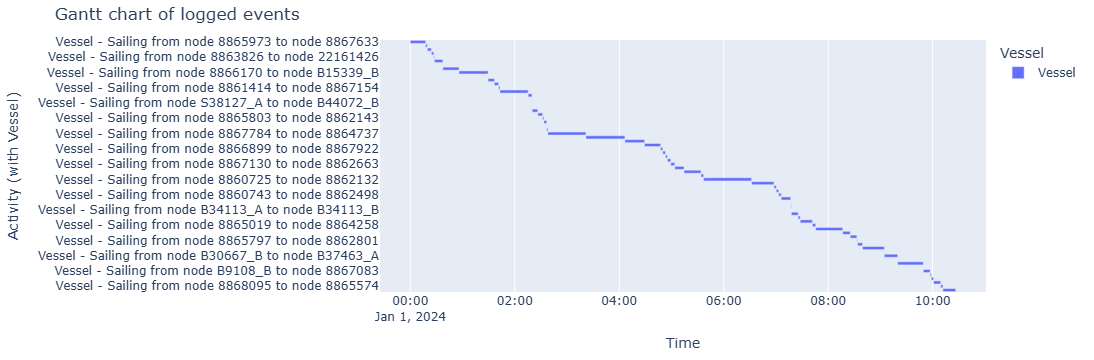

In [25]:
generate_vessel_gantt_chart(df_eventtable)

In [26]:
duration = df_eventtable['duration (s)'].sum()
distance = df_eventtable['distance (m)'].sum()
energy   = df_eventtable_energy_fuel['total_energy (kWh)'].sum()
energy   = df_eventtable_energy_H2['total_energy (kWh)'].sum()

diesel   = df_eventtable_energy_fuel['diesel_consumption (g)'].sum()
diesel_kg = diesel/1000
H2       = df_eventtable_energy_H2['H2_consumption (g)'].sum()
H2_kg    = H2/1000

print('Summed up over the complete trip:')
print('{} sailed {:.1f} m in {:.1f} s, which is {}'.format(vessel.name, distance, duration, str(datetime.timedelta(seconds=duration))))
print('{} consumed {:.2f} kWh which is {:.2f} kg diesel or {:.2f} kg H2'.format(vessel.name, energy, diesel_kg, H2_kg))


Summed up over the complete trip:
Vessel sailed 106449.1 m in 37584.7 s, which is 10:26:24.742980
Vessel consumed 7527.31 kWh which is 1877.69 kg diesel or 502.32 kg H2


In [27]:
print("P_partial =", vessel.P_partial)
print("C_partial_load_PEMFC =", vessel.C_partial_load_PEMFC)

# Curious if this works too but it doesn't yet
# print("total_LH2_consumption_PEMFC_mass =", vessel.total_LH2_consumption_PEMFC_mass)

P_partial = 0.24033084066827817
C_partial_load_PEMFC = 1.0


In [28]:
for u, v, data in FG.edges(data=True):
    print (u, "->", v)
    print(data)
    break

8861095 -> 8864054
{'GeoType': 'section', 'Name': 'Vaarwegvak van 0 tot 2 - H', 'Length': 2.346, 'GeneralDepth': 4, 'GeneralLength': nan, 'GeneralWidth': nan, 'SeaFairingDepth': nan, 'PushedLength': nan, 'PushedWidth': nan, 'GeneralHeight': nan, 'SeaFairingLength': nan, 'SeaFairingWidth': nan, 'CoupledLength': nan, 'CoupledWidth': nan, 'PushedDepth': nan, 'WidePushedDepth': nan, 'CoupledDepth': nan, 'WidePushedLength': nan, 'WidePushedWidth': nan, 'SeaFairingHeight': nan, 'Id_navigability': nan, 'Classification': nan, 'Code': nan, 'Description': nan, 'length_deg': nan, 'length': 0.0255813258548747, 'Wkt': 'LINESTRING (3.54535894046351 51.727661900382, 3.5602008295784 51.742791566037, 3.56379034355024 51.7453141508194)', 'StartJunctionId': '8861095', 'EndJunctionId': '8864054', 'subgraph': 0, 'length_m': 2835.225880186762, 'geometry': <LINESTRING (3.545 51.728, 3.56 51.743, 3.564 51.745)>}


In [29]:
# print("GeneralDepth =",FG.edges.GeneralDepth)

Makes sense that P_partial is constant throughout the trip because for some reason the P_given is constant too. I'm curious to see if that changes if the speed is constant. Basically dont understand why the speed changes anyways? The resistance is constant too right? Nothing changes on the waterway, depth is constant. Or is it not??? Yes it is 